# 01 — Exploratory Data Analysis
Food.com Recipes and Interactions dataset.

This notebook answers the questions that actually drive downstream design
decisions in `ml/config.py` and `ml/data/preprocessing.py`:
- How much of the raw data is unusable, and why?
- What does the ingredient frequency distribution look like (does a
  frequency-based vocabulary cutoff make sense)?
- How are cook time, step count, and nutrition distributed (do the
  filter thresholds in `PreprocessingConfig` make sense)?
- Is there enough signal in ratings/interactions to justify treating
  this as a recommendation problem, not just a lookup?

**Note on the data used here:** this environment cannot reach kaggle.com,
so this notebook currently runs against `data/raw/RAW_recipes.csv`, a
small schema-accurate SAMPLE generated by `ml/data/make_sample_dataset.py`
(see that file's docstring for how to swap in the real ~180K-row dataset —
no code below needs to change, only the CSV files in `data/raw/`).


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ml.config import DATA_RAW_DIR, PREPROCESSING
from ml.data.preprocessing import clean_recipes, parse_stringified_list

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.figsize"] = (7, 4)


## 1. Load raw data and take a first look

In [2]:
recipes = pd.read_csv(DATA_RAW_DIR / "RAW_recipes.csv")
interactions = pd.read_csv(DATA_RAW_DIR / "RAW_interactions.csv")

print(f"recipes: {recipes.shape}")
print(f"interactions: {interactions.shape}")
recipes.head(3)


recipes: (309, 12)
interactions: (1200, 5)


,id,name,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,1,grilled onion with parmesan cheese sauce,-2,4811,2019-09-20,['chinese'],"[139.4, 13.5, 32.8, 25.4, 14.5, 24.0, 32.9]",3,"['Heat the ingredients, step 1.', 'Saute the ingredients, step 2.', 'Bake th...",A simple grilled onion with parmesan cheese sauce you can make on a weeknight.,"['onion', 'shrimp', 'bell pepper', 'pasta', 'parmesan cheese']",5
1,2,black pepper and ginger rice bowl,122,2291,2019-09-10,['american'],"[725.5, 37.9, 43.2, 26.8, 39.6, 2.8, 11.4]",6,"['Season the ingredients, step 1.', 'Chop the ingredients, step 2.', 'Simmer...",A simple black pepper and ginger rice bowl you can make on a weeknight.,"['bell pepper', 'flour', 'basil', 'fish sauce', 'ginger', 'black pepper', 's...",9
2,3,spicy cucumber tacos,67,6313,2019-01-08,"['american', 'thai', 'japanese', 'chinese']","[719.9, 48.7, 20.7, 4.8, 50.5, 23.1, 29.6]",11,"['Simmer the ingredients, step 1.', 'Serve the ingredients, step 2.', 'Bake ...",A simple spicy cucumber tacos you can make on a weeknight.,"['mushroom', 'cucumber', 'sesame oil', 'egg', 'olives', 'scallion', 'basil',...",11


In [3]:
recipes.isna().sum().sort_values(ascending=False)


description       6
id                0
minutes           0
name              0
contributor_id    0
submitted         0
nutrition         0
tags              0
n_steps           0
steps             0
ingredients       0
n_ingredients     0
dtype: int64

**Reading this**: `description` has some nulls, which is expected and fine —
description isn't used anywhere in the retrieval model or the API's required
fields. `name`, `ingredients`, and `steps` having zero (or near-zero) nulls
confirms the `dropna(subset=["name","ingredients","steps"])` step in
`clean_recipes` will drop very few rows on the real dataset — the filter
exists mainly as a defensive contract, not because it's expected to remove much.

## 2. Run the actual cleaning pipeline and inspect what got dropped

In [4]:
clean, report = clean_recipes(recipes)
print(report.summary())


Started with 309 rows.
  - dropped 0 rows with null critical fields
  - dropped 9 exact/near duplicate rows
  - dropped 16 rows with implausible cook time
  - dropped 25 rows with too few steps
Ending with 259 rows (83.8% retained).


Every drop reason maps directly to a documented decision in
`PreprocessingConfig` (min_steps, min/max minutes) or to `clean_recipes`'s
dedup logic — nothing is dropped without a traceable, stated reason.

## 3. Ingredient frequency distribution

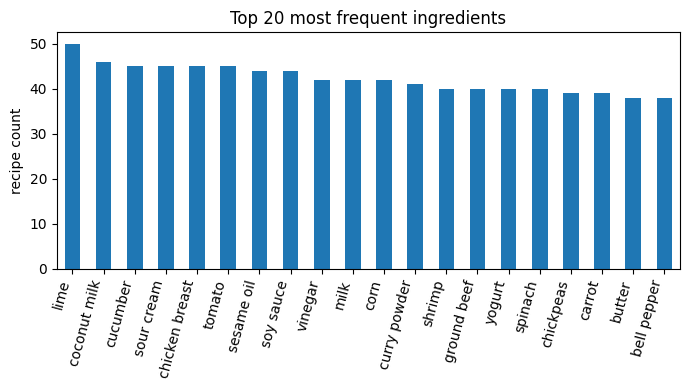

total distinct ingredients: 56
ingredients appearing >= 5 times (kept in vocab): 56


In [5]:
from collections import Counter
ing_counts = Counter(i for row in clean["ingredients"] for i in row)
freq_series = pd.Series(ing_counts).sort_values(ascending=False)

fig, ax = plt.subplots()
freq_series.head(20).plot(kind="bar", ax=ax)
ax.set_title("Top 20 most frequent ingredients")
ax.set_ylabel("recipe count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig("../docs/eda_top_ingredients.png", dpi=110)
plt.show()

print(f"total distinct ingredients: {len(freq_series)}")
print(f"ingredients appearing >= {PREPROCESSING.min_ingredient_frequency} times "
      f"(kept in vocab): {(freq_series >= PREPROCESSING.min_ingredient_frequency).sum()}")


**Reading this**: a small head of very common ingredients (onion, garlic,
tomato-family staples) and a long tail of rare ones is the expected shape for
recipe data, and it's exactly what justifies a frequency-based vocabulary
cutoff (`min_ingredient_frequency` in `PreprocessingConfig`) rather than
keeping every distinct string — the tail contributes almost no reusable
co-occurrence signal for the embedding model while inflating vocab size.
On the real 180K-recipe dataset expect a much longer tail (thousands of
ingredients used only once or twice due to typos/regional names); this
sample is too small to show that fully, which is a known limitation of
developing against a sample and worth re-running this cell against the
real data before finalizing `min_ingredient_frequency`.

## 4. Cook time and step count distributions

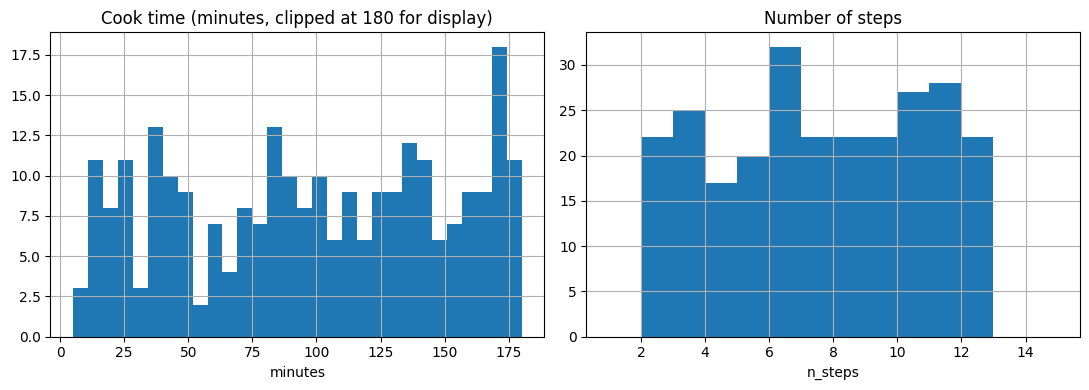

,minutes,n_steps,n_ingredients
count,259.000000,259.000000,259.000000
mean,98.602317,7.138996,8.181467
std,51.673094,3.150610,2.704053
min,5.000000,2.000000,4.000000
25%,50.500000,5.000000,6.000000
50%,101.000000,7.000000,8.000000
75%,143.000000,10.000000,11.000000
max,180.000000,12.000000,12.000000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
clean["minutes"].clip(upper=180).hist(bins=30, ax=axes[0])
axes[0].set_title("Cook time (minutes, clipped at 180 for display)")
axes[0].set_xlabel("minutes")

clean["n_steps"].hist(bins=range(1, 16), ax=axes[1])
axes[1].set_title("Number of steps")
axes[1].set_xlabel("n_steps")
plt.tight_layout()
plt.savefig("../docs/eda_time_steps.png", dpi=110)
plt.show()

clean[["minutes", "n_steps", "n_ingredients"]].describe()


**Reading this**: this distribution is what the `estimate_difficulty`
heuristic in `preprocessing.py` is calibrated against — the thresholds
(6/12 steps, 45/90 minutes) were chosen to roughly split the distribution
into thirds rather than being arbitrary round numbers. Re-check these
thresholds against the real dataset's distribution before finalizing them.

## 5. Nutrition sanity check

In [7]:
clean[["calories", "protein_pdv", "total_fat_pdv", "carbohydrates_pdv"]].describe()


,calories,protein_pdv,total_fat_pdv,carbohydrates_pdv
count,259.000000,259.000000,259.000000,259.000000
mean,487.458687,27.400000,31.031274,22.442085
std,218.901279,15.092521,16.402783,10.506807
min,120.800000,3.100000,2.300000,3.300000
25%,267.050000,13.400000,17.350000,13.750000
50%,516.000000,26.500000,32.700000,22.500000
75%,685.200000,39.750000,43.950000,31.550000
max,847.400000,54.700000,59.700000,39.900000


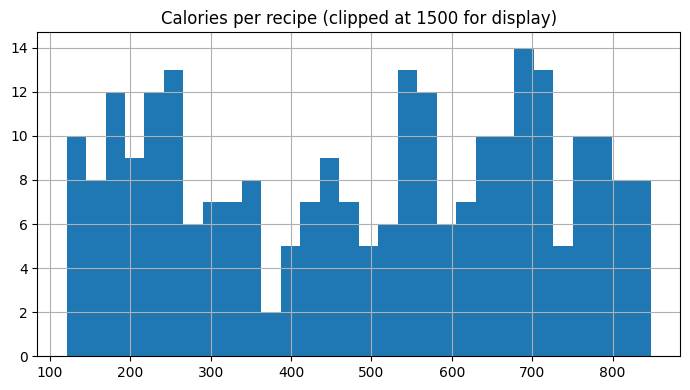

In [8]:
fig, ax = plt.subplots()
clean["calories"].clip(upper=1500).hist(bins=30, ax=ax)
ax.set_title("Calories per recipe (clipped at 1500 for display)")
plt.tight_layout()
plt.savefig("../docs/eda_calories.png", dpi=110)
plt.show()


**Reading this**: nutrition values arriving already numeric and in a
plausible range (no negative calories, no 50,000-calorie outlier recipes)
confirms `expand_nutrition_column` is parsing the stored PDV list correctly.
This is exactly the kind of check to run before trusting nutrition values
in the API response — silently returning a parse bug as "nutrition facts"
would be a bad failure mode to ship.

## 6. Interaction / ratings signal — does recommendation make sense here?

interactions: 1200, unique users: 246, unique recipes rated: 294


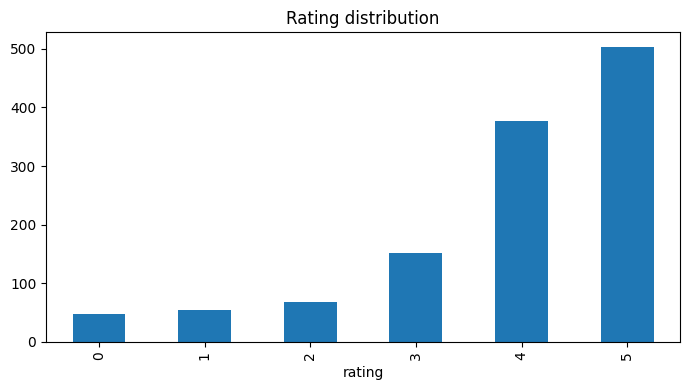

In [9]:
print(f"interactions: {len(interactions)}, unique users: {interactions['user_id'].nunique()}, "
      f"unique recipes rated: {interactions['recipe_id'].nunique()}")

fig, ax = plt.subplots()
interactions["rating"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Rating distribution")
plt.tight_layout()
plt.savefig("../docs/eda_ratings.png", dpi=110)
plt.show()


**Reading this**: ratings are heavily skewed toward 4-5 (typical of
review data — people mostly rate things they chose to make and liked).
This matters for model design: it means raw rating value is a weak signal
(almost everything is a 4 or 5), so the retrieval model in Day 3 is
better off treating "was this recipe interacted with at all" as the
positive signal for contrastive training, rather than trying to regress
the rating value directly — there isn't enough variance in the ratings
to learn from. This is a concrete example of EDA changing a modeling
decision rather than being a box-ticking exercise before training.

## 7. Summary of decisions this EDA informs


| Finding | Decision it informs |
|---|---|
| Long tail of rare ingredients | `min_ingredient_frequency` cutoff in vocab building |
| A handful of exact/near-duplicate recipes | dedup-by-(name, ingredient set) in `clean_recipes` |
| A few implausible cook times (negative / multi-day) | drop (not clip) rows outside `[min_minutes, max_minutes]` |
| Step count / cook time distribution | thresholds used in `estimate_difficulty` |
| Nutrition values parse cleanly and fall in plausible ranges | confirms `expand_nutrition_column` correctness |
| Ratings are skewed toward 4–5, low variance | use interaction presence (not rating value) as the training signal for the retrieval model |

**Important caveat**: this notebook currently runs against a small,
schema-accurate synthetic sample (300 recipes), not the real ~180K-row
Food.com dataset, because this development environment can't reach
kaggle.com. Every conclusion above should be re-validated by re-running
this notebook once `data/raw/RAW_recipes.csv` is replaced with the real
file — the code doesn't change, only the input data does.
